<a href="https://colab.research.google.com/github/mania605/-9-/blob/master/20250804_DIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 길이(length), 무게(g)
# bream(도미), smelt(빙어)

# 문제집: 길이와 무게
# 정답지: 타겟

fish = pd.read_csv("/content/fish.csv")

X = fish[['length', 'weight']].values
Y = fish['target'].values

<Axes: xlabel='length', ylabel='weight'>

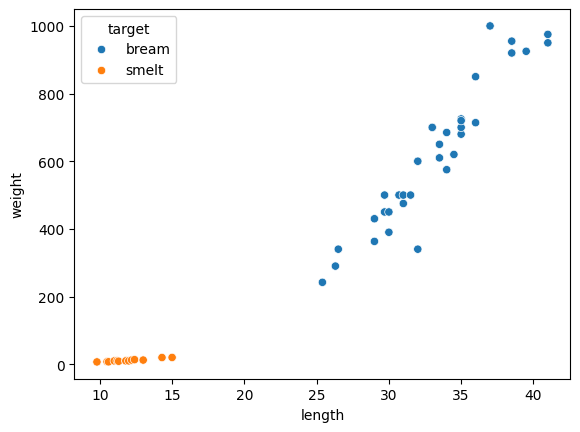

In [ ]:
import seaborn as sns
sns.scatterplot(data=fish, x = 'length', y = 'weight', hue = 'target')

In [ ]:
# 머신러닝 모델 만들기 (K 최근접 이웃)
from sklearn.neighbors import KNeighborsClassifier # K 이웃 분류 모델

# 모델 생성
model = KNeighborsClassifier()

# 모델 학습
model.fit(X, Y)

KNeighborsClassifier()

In [ ]:
# 길이가 35cm고 무게가 650g인 생선 예측하기
my_data = [35, 650]
model.predict([my_data])

array(['bream'], dtype=object)

In [ ]:
# Pandas : 행과 열로 구성된 데이터를 활용하는 도구(통계분석, 데이터전처리 & 가공)
# Sklearn : 머신러닝 & 머신러닝에 관련된 데이터 전처리를 하는 도구

# 얼만큼 신뢰해야하는가? 성능을 평가하는 단계

pred = model.predict(X) # 예측값
print(pred)

['bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream'
 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream'
 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream'
 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'smelt'
 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt'
 'smelt' 'smelt' 'smelt' 'smelt']


In [ ]:
print(Y) # 실제값

['bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream'
 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream'
 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream'
 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'bream' 'smelt'
 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt' 'smelt'
 'smelt' 'smelt' 'smelt' 'smelt']


In [ ]:
# X를 예측한 값과 Y를 비교해서 정확도로 표현해라.
model.score(X, Y)

1.0

In [ ]:
pred = model.predict(X) # 예측값
model.score(X, Y)

1.0

In [ ]:
# 최대한 많이 훈련데이터에 쏟아야함!
# 데이터가 1000만개 : (999만개 : 1만개)

# Google = 8 : 2
# Sklearn = 75 : 25

from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2, stratify=Y)

In [ ]:
model = KNeighborsClassifier()
model.fit(train_x, train_y)

pred = model.predict(test_x)
print(pred) # 모르는 데이터를 예측한 값

['bream' 'bream' 'smelt' 'smelt' 'bream' 'smelt' 'bream' 'bream' 'bream'
 'bream']


In [ ]:
print(test_y) # 실제값

['bream' 'bream' 'smelt' 'smelt' 'bream' 'smelt' 'bream' 'bream' 'bream'
 'bream']


In [ ]:
# test_x로 예측한 값과 test_y를 비교해서 정확도로 표현해라!
model.score(test_x, test_y)

1.0

In [ ]:
my_data = [25, 150]
model.predict([my_data])

array(['smelt'], dtype=object)

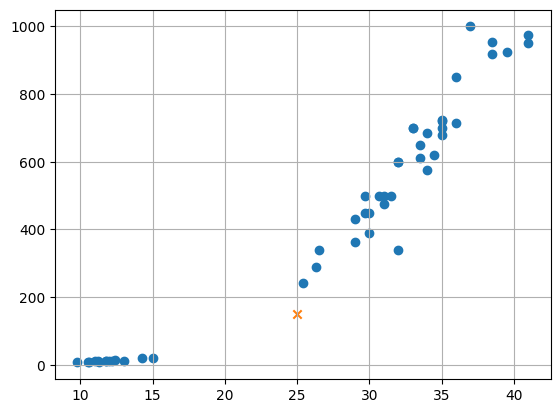

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(fish['length'], fish['weight'])
plt.scatter(25, 150, marker = 'x')

plt.grid()
plt.show()

In [ ]:
mean = train_x.mean(axis = 0)
std = train_x.std(axis = 0)

train_scaled = (train_x - mean) / std
test_scaled = (test_x - mean) / std

model = KNeighborsClassifier()
model.fit(train_scaled, train_y)
model.score(test_scaled, test_y)

1.0

In [ ]:
my_data = ([25, 150] - mean) / std
model.predict([my_data])

array(['bream'], dtype=object)

In [ ]:
# 데이터 불러오기 - 문제집, 정답지 - 데이터 분할 - 데이터표준화 - 모델생성 - 학습 - 평가

# 생선 7종류 / 5개의 특성 // fish2 분류 모델 만들고 성능 평가하기!

fish2 = pd.read_csv("/content/fish2.csv")

X = fish2[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].values
Y = fish2['Species'].values

train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2, stratify=Y)

mean = train_x.mean(axis = 0)
std = train_x.std(axis = 0)

train_scaled = (train_x - mean) / std
test_scaled = (test_x - mean) / std

model = KNeighborsClassifier()
model.fit(train_scaled, train_y)
model.score(test_scaled, test_y)

0.8125

In [ ]:
# K 최근접 이웃 분류 모델 : 가장 가까운 데이터 (기본값 5개)

fish2 = pd.read_csv("/content/fish2.csv")

X = fish2[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].values
Y = fish2['Species'].values

train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size = 0.2, stratify=Y)

mean = train_x.mean(axis = 0)
std = train_x.std(axis = 0)

train_scaled = (train_x - mean) / std
test_scaled = (test_x - mean) / std

model = KNeighborsClassifier()
model.fit(train_scaled, train_y)

for n in range(1, 31):

    # 이 모델의 이웃 숫자를 n으로 바꿔라.
    model.n_neighbors = n

    score = model.score(test_scaled, test_y)
    print(f"이웃수: {n}, 정확도 : {score}")

이웃수: 1, 정확도 : 0.875
이웃수: 2, 정확도 : 0.8125
이웃수: 3, 정확도 : 0.8125
이웃수: 4, 정확도 : 0.8125
이웃수: 5, 정확도 : 0.8125
이웃수: 6, 정확도 : 0.75
이웃수: 7, 정확도 : 0.78125
이웃수: 8, 정확도 : 0.78125
이웃수: 9, 정확도 : 0.78125
이웃수: 10, 정확도 : 0.75
이웃수: 11, 정확도 : 0.78125
이웃수: 12, 정확도 : 0.71875
이웃수: 13, 정확도 : 0.6875
이웃수: 14, 정확도 : 0.71875
이웃수: 15, 정확도 : 0.6875
이웃수: 16, 정확도 : 0.6875
이웃수: 17, 정확도 : 0.6875
이웃수: 18, 정확도 : 0.6875
이웃수: 19, 정확도 : 0.6875
이웃수: 20, 정확도 : 0.65625
이웃수: 21, 정확도 : 0.65625
이웃수: 22, 정확도 : 0.65625
이웃수: 23, 정확도 : 0.65625
이웃수: 24, 정확도 : 0.65625
이웃수: 25, 정확도 : 0.625
이웃수: 26, 정확도 : 0.625
이웃수: 27, 정확도 : 0.625
이웃수: 28, 정확도 : 0.625
이웃수: 29, 정확도 : 0.625
이웃수: 30, 정확도 : 0.625


In [ ]:
model.n_neighbors = 3

In [ ]:
# 정확도

test_y # 실제값

array(['Smelt', 'Whitefish', 'Roach', 'Bream', 'Bream', 'Smelt', 'Pike',
       'Bream', 'Perch', 'Perch', 'Bream', 'Perch', 'Perch', 'Roach',
       'Smelt', 'Perch', 'Perch', 'Pike', 'Pike', 'Roach', 'Perch',
       'Parkki', 'Perch', 'Bream', 'Pike', 'Perch', 'Perch', 'Parkki',
       'Perch', 'Bream', 'Roach', 'Bream'], dtype=object)

In [ ]:
model.predict(test_scaled) # 예측값

array(['Smelt', 'Perch', 'Roach', 'Bream', 'Bream', 'Smelt', 'Pike',
       'Bream', 'Perch', 'Perch', 'Bream', 'Perch', 'Perch', 'Perch',
       'Smelt', 'Perch', 'Roach', 'Pike', 'Pike', 'Perch', 'Perch',
       'Parkki', 'Smelt', 'Bream', 'Pike', 'Perch', 'Perch', 'Parkki',
       'Perch', 'Bream', 'Perch', 'Bream'], dtype=object)

In [ ]:
model.score(test_scaled, test_y)

0.8125

In [ ]:
# 정확도 99.99%
# 정상품 / 불량품 구별하는 모델이라면?

# 정상품 100만개 / 불량품 100개 = 100만개 100개
# 이것은 무조건 정상품입니다. 라고만 예측해도 99.99%

# 정확도: 예측한것과 실제값 중에 맞은 비율
# 정밀도: 예측한것 중에서 몇개 맞았냐의 비율
# 재현율: 전체에서 잡아낸게 총 몇%냐

from sklearn.metrics import classification_report

pred = model.predict(test_scaled)

report = classification_report(test_y, pred)
print(report)